Original Data Distribution: Counter({1: 9652, 0: 112, 3: 95, 2: 78, 5: 45, 4: 18})
After OverSampling Distribution: Counter({1: 9652, 3: 9652, 5: 9652, 2: 9652, 4: 9652, 0: 9652})
Iteration 1/50 - Best Accuracy: 99.93%
Iteration 2/50 - Best Accuracy: 99.93%
Iteration 3/50 - Best Accuracy: 99.93%
Iteration 4/50 - Best Accuracy: 99.93%
Iteration 5/50 - Best Accuracy: 99.93%
Iteration 6/50 - Best Accuracy: 99.93%
Iteration 7/50 - Best Accuracy: 99.93%
Iteration 8/50 - Best Accuracy: 99.93%
Iteration 9/50 - Best Accuracy: 99.93%
Iteration 10/50 - Best Accuracy: 99.93%
Iteration 11/50 - Best Accuracy: 99.93%
Iteration 12/50 - Best Accuracy: 99.93%
Iteration 13/50 - Best Accuracy: 99.93%
Iteration 14/50 - Best Accuracy: 99.93%
Iteration 15/50 - Best Accuracy: 99.93%
Iteration 16/50 - Best Accuracy: 99.93%
Iteration 17/50 - Best Accuracy: 99.93%
Iteration 18/50 - Best Accuracy: 99.93%
Iteration 19/50 - Best Accuracy: 99.93%
Iteration 20/50 - Best Accuracy: 99.93%
Iteration 21/50 - Best Accura

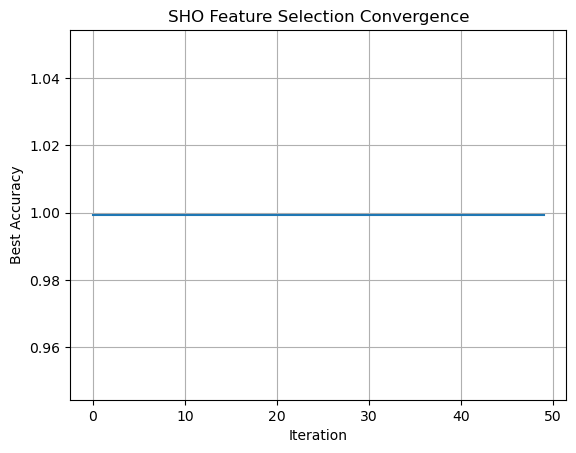


✅ Model saved as 'Best_Model_FeatureSelection.pkl'


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from collections import Counter
import matplotlib.pyplot as plt
import random
import joblib

# -------------------------------
# Step 1: Load Data and Preprocess
# -------------------------------
data = pd.read_csv('Dataset.csv')

# Drop unneeded columns
del data['UDI']
del data['Product ID']
del data['Target']
del data['Type']

df = data.dropna()

# Encode Target Label
le = LabelEncoder()
df['Failure_Type'] = le.fit_transform(df['Failure_Type']).astype(int)

# Features and Target
x1 = df.drop(labels='Failure_Type', axis=1)
y1 = df['Failure_Type']

# Handle Class Imbalance
ros = RandomOverSampler(random_state=42)
x, y = ros.fit_resample(x1, y1)

print(f"Original Data Distribution: {Counter(y1)}")
print(f"After OverSampling Distribution: {Counter(y)}")

# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y
)

# Convert to NumPy Arrays for Indexing
x_train = x_train.values
x_test = x_test.values
y_train = y_train.values
y_test = y_test.values

DIMENSIONS = x_train.shape[1]

# -------------------------------
# Step 2: Define Optimization Helpers
# -------------------------------

def fitness_function(feature_subset):
    selected_features = [idx for idx in range(len(feature_subset)) if feature_subset[idx] == 1]
    if len(selected_features) == 0:
        return 0  # Avoid empty feature set

    clf = RandomForestClassifier(random_state=42)
    clf.fit(x_train[:, selected_features], y_train)
    y_pred = clf.predict(x_test[:, selected_features])
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

def slime_mould_update(position, best_position):
    return np.clip(position + np.random.uniform(-0.1, 0.1, size=position.shape), 0, 1)

def harris_hawk_update(position, best_position):
    return np.clip(position + np.random.uniform(-0.05, 0.05, size=position.shape) * (best_position - position), 0, 1)

def binarize(position):
    return np.where(position > 0.5, 1, 0)

# -------------------------------
# Step 3: Hybrid SHO Algorithm
# -------------------------------

def SHO(num_agents, max_iter, dim):
    positions = np.random.rand(num_agents, dim)
    fitness = np.zeros(num_agents)

    for i in range(num_agents):
        features = binarize(positions[i])
        fitness[i] = fitness_function(features)

    best_idx = np.argmax(fitness)
    best_position = positions[best_idx].copy()
    best_fitness = fitness[best_idx]

    convergence_curve = []

    for t in range(max_iter):
        for i in range(num_agents):
            if random.random() < 0.5:
                positions[i] = slime_mould_update(positions[i], best_position)
            else:
                positions[i] = harris_hawk_update(positions[i], best_position)

            positions[i] = np.clip(positions[i], 0, 1)

            features = binarize(positions[i])
            fitness[i] = fitness_function(features)

            if fitness[i] > best_fitness:
                best_fitness = fitness[i]
                best_position = positions[i].copy()

        convergence_curve.append(best_fitness)
        print(f"Iteration {t+1}/{max_iter} - Best Accuracy: {best_fitness*100:.2f}%")

    return binarize(best_position), best_fitness, convergence_curve

# -------------------------------
# Step 4: Run SHO for Feature Selection
# -------------------------------

NUM_AGENTS = 20
MAX_ITER = 50

best_features, best_accuracy, convergence = SHO(NUM_AGENTS, MAX_ITER, DIMENSIONS)

print("\n✅ Best Selected Feature Mask:")
print(best_features)
print(f"✅ Best Accuracy Found: {best_accuracy*100:.2f}%")

# -------------------------------
# Step 5: Train Final Model
# -------------------------------

final_clf = RandomForestClassifier(random_state=42)
final_clf.fit(x_train[:, best_features == 1], y_train)
final_pred = final_clf.predict(x_test[:, best_features == 1])
final_accuracy = accuracy_score(y_test, final_pred)

print(f"\n🎯 Final Test Accuracy: {final_accuracy*100:.2f}%")

# Plot Convergence Curve
plt.plot(convergence)
plt.title('SHO Feature Selection Convergence')
plt.xlabel('Iteration')
plt.ylabel('Best Accuracy')
plt.grid(True)
plt.show()

# Save Final Model
joblib.dump(final_clf, 'Best_Model_FeatureSelection.pkl')
print("\n✅ Model saved as 'Best_Model_FeatureSelection.pkl'")
